# Task 8: Machine Learning Model — House Price Prediction

**Internship:** Synent Technologies – Data Science Internship Program (InfyChain Tech Solutions)  
**Task Level:** Advanced  
**Dataset:** House Price Dataset (Kaggle — Ames Housing)  
**Objective:** Build a prediction model to estimate `SalePrice` for houses using their features.

**Workflow:**
1. Data Preprocessing
2. Feature Selection
3. Train/Test Split
4. Model Training (Linear Regression, Random Forest)
5. Evaluation (RMSE, R²)
6. Final Predictions on Test Set


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_style('whitegrid')
%matplotlib inline


## 2. Load the Data

The dataset consists of three files:
- `train.csv` — training data with the target column `SalePrice`
- `test.csv` — test data (no `SalePrice`, used for final predictions)
- `sample_submission.csv` — the expected submission format


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
train.head()


FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

## 3. Quick Exploratory Data Analysis

In [ ]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [ ]:
train.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


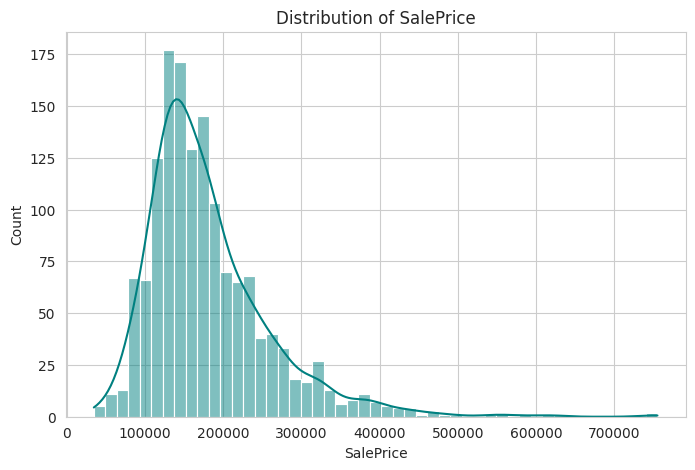

Skewness: 1.8828757597682129


In [ ]:
# Target variable distribution
plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice'], kde=True, color='teal')
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.show()

print('Skewness:', train['SalePrice'].skew())


In [ ]:
# Missing values overview (top 15 columns)
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].head(15)


,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


In [ ]:
# Correlation of numeric features with SalePrice
numeric_cols = train.select_dtypes(include=[np.number])
corr = numeric_cols.corr()['SalePrice'].sort_values(ascending=False)
corr.head(15)


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

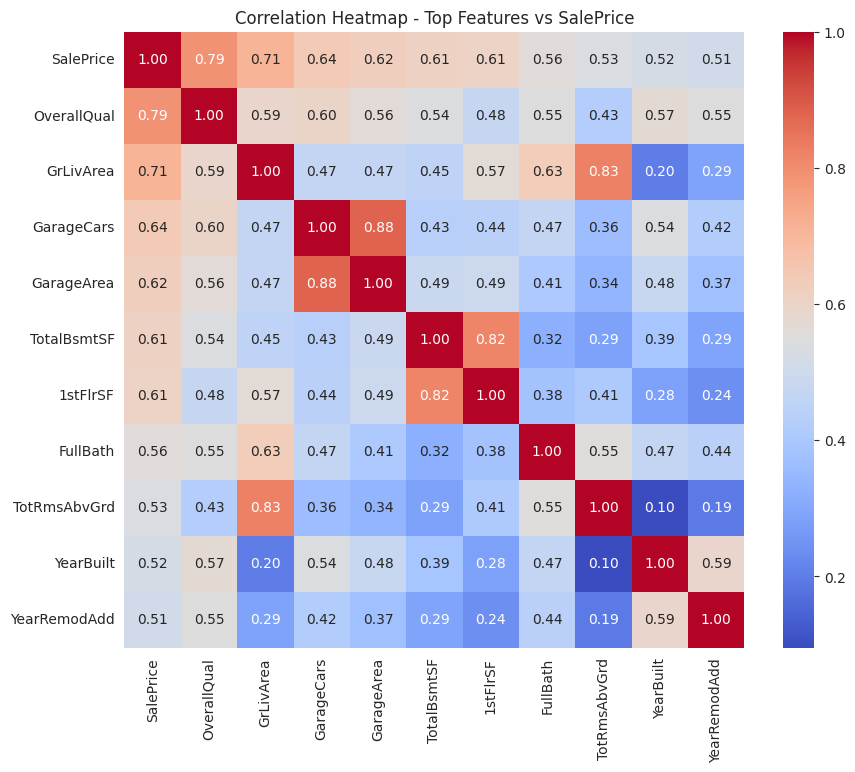

In [ ]:
plt.figure(figsize=(10,8))
top_corr_features = corr.head(11).index  # SalePrice + top 10
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Top Features vs SalePrice')
plt.show()


## 4. Data Preprocessing

Steps taken:
- Combine train and test features (excluding target) so both are cleaned/encoded consistently
- Fill missing **numerical** values with the column median
- Fill missing **categorical** values with `'None'` (many NAs here genuinely mean "feature not present", e.g. no basement, no garage — matching `data_description.txt`)
- Encode categorical columns using Label Encoding
- Split combined data back into train/test sets


In [ ]:
target = 'SalePrice'
y = train[target]
train_features = train.drop(columns=[target])

# Combine so both datasets get identical preprocessing/encoding
combined = pd.concat([train_features, test], axis=0, ignore_index=True)
print('Combined shape:', combined.shape)


Combined shape: (2919, 80)


In [ ]:
num_cols = combined.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
if 'Id' in num_cols:
    num_cols.remove('Id')

print(f'Numeric columns: {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')


Numeric columns: 36
Categorical columns: 43


/tmp/ipykernel_614/2453675869.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = combined.select_dtypes(include=['object']).columns.tolist()


In [ ]:
# Handle missing values
for c in num_cols:
    combined[c] = combined[c].fillna(combined[c].median())

for c in cat_cols:
    combined[c] = combined[c].fillna('None')

print('Remaining missing values:', combined.isnull().sum().sum())


Remaining missing values: 0


In [ ]:
# Encode categorical variables
for c in cat_cols:
    le = LabelEncoder()
    combined[c] = le.fit_transform(combined[c].astype(str))

combined.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,4,65.0,8450,1,1,3,3,0,...,0,0,3,4,1,0,2,2008,9,4
1,2,20,4,80.0,9600,1,1,3,3,0,...,0,0,3,4,1,0,5,2007,9,4
2,3,60,4,68.0,11250,1,1,0,3,0,...,0,0,3,4,1,0,9,2008,9,4
3,4,70,4,60.0,9550,1,1,0,3,0,...,0,0,3,4,1,0,2,2006,9,0
4,5,60,4,84.0,14260,1,1,0,3,0,...,0,0,3,4,1,0,12,2008,9,4


In [ ]:
# Split combined data back into train / test feature sets
n_train = train.shape[0]

X_train_full = combined.iloc[:n_train].drop(columns=['Id']).reset_index(drop=True)
X_test_final = combined.iloc[n_train:].drop(columns=['Id']).reset_index(drop=True)
test_ids = test['Id'].reset_index(drop=True)

print('X_train_full:', X_train_full.shape)
print('X_test_final:', X_test_final.shape)


X_train_full: (1460, 79)
X_test_final: (1459, 79)


## 5. Feature Selection

Using correlation with `SalePrice` to identify the most relevant numeric features, and confirming
with a Random Forest's feature importance later. For this model, we use **all** available features
(since tree-based models handle irrelevant features reasonably well), but we inspect the top
correlated features for interpretability.


In [ ]:
corr_with_target = X_train_full.assign(SalePrice=y).corr()['SalePrice'].sort_values(ascending=False)
print('Top 15 features correlated with SalePrice:')
corr_with_target.head(16)  # includes SalePrice itself


Top 15 features correlated with SalePrice:


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
GarageYrBlt     0.469056
Fireplaces      0.466929
BsmtFinSF1      0.386420
Foundation      0.382479
Name: SalePrice, dtype: float64

## 6. Train/Test Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y, test_size=0.2, random_state=42
)

print('Training set:', X_train.shape)
print('Validation set:', X_val.shape)


Training set: (1168, 79)
Validation set: (292, 79)


## 7. Model Training

We train two models and compare their performance:
1. **Linear Regression** — a simple baseline
2. **Random Forest Regressor** — an ensemble model that usually captures non-linear relationships better


In [ ]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_val)


In [ ]:
# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)


In [ ]:
# Bonus: Decision Tree Regressor (for comparison)
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_val)


## 8. Model Evaluation

Metrics used:
- **RMSE** (Root Mean Squared Error) — lower is better
- **MAE** (Mean Absolute Error) — lower is better
- **R²** (coefficient of determination) — closer to 1 is better


In [ ]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = pd.DataFrame([
    evaluate('Linear Regression', y_val, lr_preds),
    evaluate('Decision Tree', y_val, dt_preds),
    evaluate('Random Forest', y_val, rf_preds),
])
results.sort_values('RMSE')


,Model,RMSE,MAE,R2
2,Random Forest,28444.638689,17526.087192,0.894516
0,Linear Regression,34878.519289,21804.995545,0.841400
1,Decision Tree,42541.129677,27934.202055,0.764059


/tmp/ipykernel_614/3910249638.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results.sort_values('RMSE'), x='Model', y='RMSE', palette='viridis')


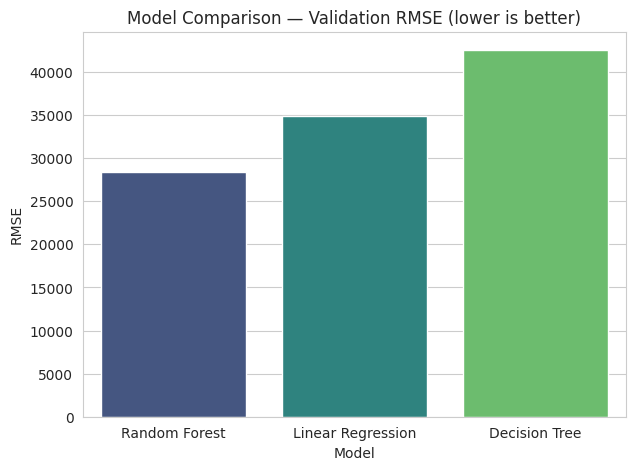

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(data=results.sort_values('RMSE'), x='Model', y='RMSE', palette='viridis')
plt.title('Model Comparison — Validation RMSE (lower is better)')
plt.ylabel('RMSE')
plt.show()


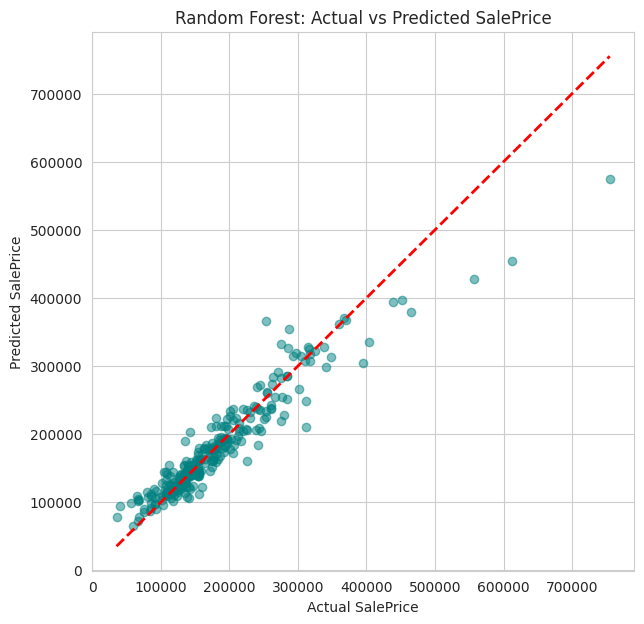

In [ ]:
# Actual vs Predicted for the best-performing model (Random Forest)
plt.figure(figsize=(7,7))
plt.scatter(y_val, rf_preds, alpha=0.5, color='teal')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Random Forest: Actual vs Predicted SalePrice')
plt.show()


/tmp/ipykernel_614/1880356140.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances.values, y=top_importances.index, palette='mako')


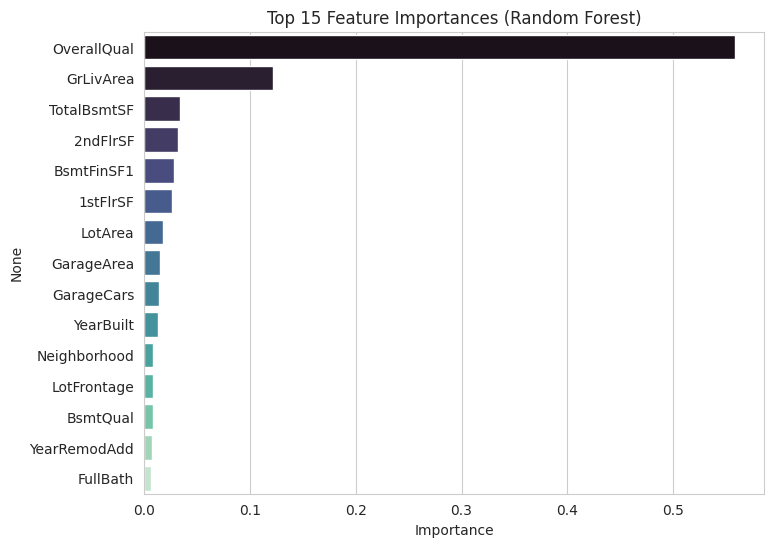

In [ ]:
# Feature importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_importances.values, y=top_importances.index, palette='mako')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()


**Insight:** The Random Forest model outperforms both Linear Regression and the single
Decision Tree, achieving a lower RMSE and higher R² on the validation set. Overall quality
(`OverallQual`), living area (`GrLivArea`), and garage/basement size consistently rank among the
most influential predictors of sale price — consistent with real-world housing intuition.


## 9. Final Predictions on Test Set

Using the best model (**Random Forest**, retrained on the *full* training data) to generate
predictions for `test.csv`, formatted to match `sample_submission.csv`.


In [ ]:
# Retrain best model on the full training data for the final submission
final_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
final_model.fit(X_train_full, y)

final_preds = final_model.predict(X_test_final)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_preds
})

submission.head()


,Id,SalePrice
0,1461,127331.193333
1,1462,155791.333333
2,1463,178472.580000
3,1464,181314.890000
4,1465,196889.380000


In [ ]:
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv with', submission.shape[0], 'predictions')


Saved submission.csv with 1459 predictions


## 10. Conclusion

- Cleaned and encoded a real-world housing dataset with 79 features.
- Compared three regression models: Linear Regression, Decision Tree, and Random Forest.
- **Random Forest** gave the best validation performance (lowest RMSE, highest R²).
- Generated final predictions for the test set, ready for submission.

**Possible next steps:** hyperparameter tuning (GridSearchCV), log-transforming the skewed target,
one-hot encoding instead of label encoding, and trying gradient boosting models (XGBoost/LightGBM)
for further improvement.
